In [ ]:
# Cell 1: Install required packages.
# HuggingFace transformers + datasets, plus sklearn for metrics.
# Run this first, it may take 1-2 minutes.

!pip install transformers datasets scikit-learn -q
print("Done")

Done


In [ ]:
# Cell 2: Mount Google Drive.
# All data is read from here and all outputs are saved here.
# When prompted, sign in with the Google account that has
# access to the hinemo/splits folder.

from google.colab import drive
drive.mount("/content/drive")
print("Drive mounted")

Mounted at /content/drive
Drive mounted


In [ ]:
# Cell 3: Configuration.
# THIS IS THE ONLY CELL THAT DIFFERS ACROSS THE THREE NOTEBOOKS.
# Change MODEL_NAME to the model you are training.
# Everything else (hyperparameters, paths, logic) stays identical.

# ── Choose one ──────────────────────────────────────────────
# MODEL_NAME = "bert-base-multilingual-cased"   # mBERT
# MODEL_NAME = "xlm-roberta-base"             # XLM-R
MODEL_NAME = "google/muril-base-cased"      # MuRIL

# ── Paths (same across all three notebooks) ─────────────────
DRIVE_ROOT    = "/content/drive/MyDrive/hinemo"
SPLITS_DIR    = f"{DRIVE_ROOT}/splits"
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints/{MODEL_NAME.split('/')[-1]}"

TRAIN_PATH = f"{SPLITS_DIR}/hinemo_train.csv"
VAL_PATH   = f"{SPLITS_DIR}/hinemo_val.csv"
TEST_PATH  = f"{SPLITS_DIR}/hinemo_test.csv"

# ── Hyperparameters (identical across all three) ─────────────
EPOCHS        = 5
BATCH_SIZE    = 16
LEARNING_RATE = 2e-5
MAX_LENGTH    = 128
RANDOM_SEED   = 524
NUM_LABELS    = 4

EMOTION_LABELS = ["anger", "disgust", "joy", "sadness"]
LABEL2ID = {e: i for i, e in enumerate(EMOTION_LABELS)}
ID2LABEL = {i: e for i, e in enumerate(EMOTION_LABELS)}

import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Model:           {MODEL_NAME}")
print(f"Checkpoint dir:  {CHECKPOINT_DIR}")
print(f"Epochs:          {EPOCHS}")
print(f"Batch size:      {BATCH_SIZE}")
print(f"Learning rate:   {LEARNING_RATE}")
print(f"Max length:      {MAX_LENGTH}")
print(f"Random seed:     {RANDOM_SEED}")

Model:           google/muril-base-cased
Checkpoint dir:  /content/drive/MyDrive/hinemo/checkpoints/muril-base-cased
Epochs:          5
Batch size:      16
Learning rate:   2e-05
Max length:      128
Random seed:     524


In [ ]:
# Cell 4: All imports.
# Kept in one cell so it's easy to see every dependency.

import pandas as pd
import numpy as np
import torch
import json
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Use GPU if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [ ]:
# Cell 5: Load the three splits and confirm they look right.
# Prints row counts and emotion distribution for each split.

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"Train: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

print(f"\nEmotion distribution:")
print(f"{'Emotion':<12} {'Train':>8} {'Val':>8} {'Test':>8}")
for emotion in EMOTION_LABELS:
    t = (train_df["gpt_emotion"] == emotion).sum()
    v = (val_df["gpt_emotion"] == emotion).sum()
    te = (test_df["gpt_emotion"] == emotion).sum()
    print(f"{emotion:<12} {t:>8,} {v:>8,} {te:>8,}")

Train: 32,321 rows
Val:   6,926 rows
Test:  6,926 rows

Emotion distribution:
Emotion         Train      Val     Test
anger           8,658    1,855    1,855
disgust         6,089    1,304    1,305
joy            12,400    2,658    2,657
sadness         5,174    1,109    1,109


In [ ]:
# Cell 6: PyTorch Dataset class.
# Converts each row into tokenized input tensors the model
# can process. MAX_LENGTH=128 tokens handles most comments
# without wasting memory on padding to longer lengths.

class HinEmoDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.texts  = df["text"].tolist()
        self.labels = df["gpt_emotion"].map(LABEL2ID).tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=MAX_LENGTH,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [ ]:
# Cell 7: Load pretrained tokenizer and model from HuggingFace.
# AutoModelForSequenceClassification adds a 4-way classification
# head on top of the pretrained encoder.
# This downloads ~500MB-1GB depending on the model — takes
# a few minutes on first run, then cached.

print(f"Loading tokenizer and model: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading tokenizer and model: google/muril-base-cased


config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  953MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

Total parameters:     237,559,300
Trainable parameters: 237,559,300


In [ ]:
# Cell 8: Wrap datasets in DataLoaders for batched training.
# train_loader shuffles every epoch (important for training).
# val and test loaders do NOT shuffle (results must be
# reproducible and order-independent for evaluation).

train_dataset = HinEmoDataset(train_df, tokenizer)
val_dataset   = HinEmoDataset(val_df,   tokenizer)
test_dataset  = HinEmoDataset(test_df,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 2021
Val batches:   433
Test batches:  433


In [ ]:
# Cell 9: Set up optimizer and learning rate scheduler.
# AdamW with linear warmup is standard for fine-tuning
# transformer models. Warmup over first 10% of steps
# prevents large updates at the start of training from
# destabilizing the pretrained weights.

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps:         {warmup_steps}")

Total training steps: 10105
Warmup steps:         1010


In [ ]:
# Cell 10: Core training and evaluation logic.
# train_epoch: runs one full pass over the training data,
#   updating model weights via backpropagation.
# evaluate: runs the model on a dataloader WITHOUT updating
#   weights (torch.no_grad()), returns loss and macro F1.

def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, macro_f1


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, macro_f1, all_preds, all_labels

In [ ]:
# Cell 11: Main training loop.
# Trains for EPOCHS epochs, evaluating on val after each epoch.
# Saves the best model checkpoint (highest val macro F1).
# Prints loss and F1 for both train and val each epoch.
# Early stopping if val F1 doesn't improve for 2 epochs.

history = {
    "train_loss": [], "train_f1": [],
    "val_loss":   [], "val_f1":   [],
}

best_val_f1   = 0.0
patience      = 2
patience_counter = 0
best_model_path = f"{CHECKPOINT_DIR}/best_model"

print(f"Starting training: {MODEL_NAME}")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Train F1':<12} {'Val Loss':<12} {'Val F1':<10} {'Status'}")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1 = train_epoch(model, train_loader,
                                        optimizer, scheduler)
    val_loss, val_f1, _, _ = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    status = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        # Save full model + tokenizer
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        status = "✅ saved"
    else:
        patience_counter += 1
        status = f"no improvement ({patience_counter}/{patience})"

    print(f"{epoch:<8} {train_loss:<14.4f} {train_f1:<12.4f} "
          f"{val_loss:<12.4f} {val_f1:<10.4f} {status}")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch} — val F1 hasn't improved for {patience} epochs.")
        break

print(f"\nBest val macro F1: {best_val_f1:.4f}")
print(f"Best model saved to: {best_model_path}")

# Save training history
with open(f"{CHECKPOINT_DIR}/training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print("Training history saved.")

Starting training: google/muril-base-cased
Epoch    Train Loss     Train F1     Val Loss     Val F1     Status
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

1        1.1026         0.3735       0.8557       0.5659     ✅ saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2        0.7475         0.6458       0.6872       0.6932     ✅ saved


...

3        0.5597         0.7549       0.6549       0.7129     ✅ saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

4        0.4342         0.8183       0.6926       0.7158     ✅ saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

5        0.3595         0.8559       0.7351       0.7179     ✅ saved

Best val macro F1: 0.7179
Best model saved to: /content/drive/MyDrive/hinemo/checkpoints/muril-base-cased/best_model
Training history saved.


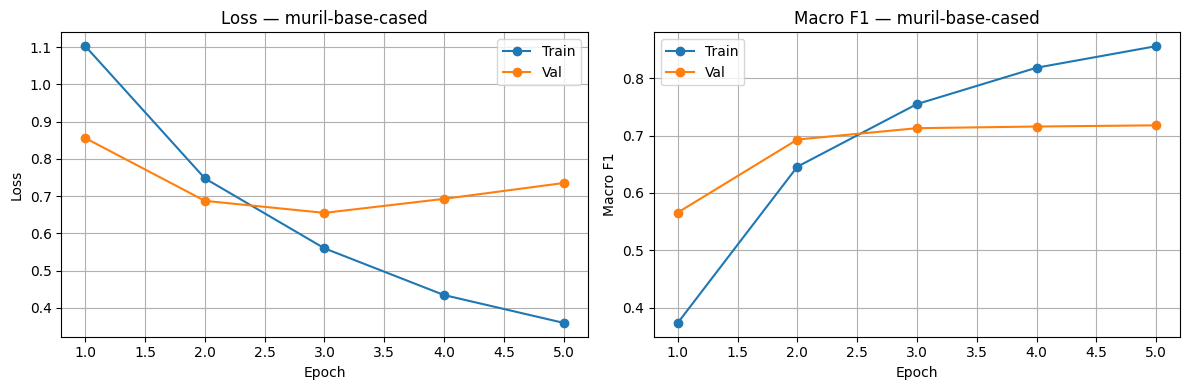

Training curves saved to: /content/drive/MyDrive/hinemo/checkpoints/muril-base-cased/training_curves.png


In [ ]:
# Cell 12: Plot loss and F1 curves for both train and val.
# Saved to Drive for inclusion in the paper.
# A well-behaved training run should show train loss
# decreasing and val loss roughly tracking it (not diverging).

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_ran = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs_ran, history["train_loss"], label="Train", marker="o")
ax1.plot(epochs_ran, history["val_loss"],   label="Val",   marker="o")
ax1.set_title(f"Loss — {MODEL_NAME.split('/')[-1]}")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_ran, history["train_f1"], label="Train", marker="o")
ax2.plot(epochs_ran, history["val_f1"],   label="Val",   marker="o")
ax2.set_title(f"Macro F1 — {MODEL_NAME.split('/')[-1]}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro F1")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plot_path = f"{CHECKPOINT_DIR}/training_curves.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Training curves saved to: {plot_path}")

In [ ]:
# Cell 13: Load the best saved checkpoint and evaluate on
# the test set. This is the number reported in the paper.
# Run this ONCE at the very end — never use test set results
# to make any decisions about the model.

from transformers import AutoModelForSequenceClassification

print("Loading best checkpoint for final test evaluation...")
best_model = AutoModelForSequenceClassification.from_pretrained(best_model_path)
best_model = best_model.to(DEVICE)

_, test_f1, test_preds, test_labels = evaluate(best_model, test_loader)

print(f"\nFinal Test Macro F1: {test_f1:.4f}")
print(f"\nPer-class classification report:")
report = classification_report(
    test_labels, test_preds,
    target_names=EMOTION_LABELS,
    digits=4,
)
print(report)

# Save classification report
report_dict = classification_report(
    test_labels, test_preds,
    target_names=EMOTION_LABELS,
    output_dict=True,
)
with open(f"{CHECKPOINT_DIR}/test_classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)

# Save confusion matrix
cm = confusion_matrix(test_labels, test_preds)
cm_df = pd.DataFrame(cm, index=EMOTION_LABELS, columns=EMOTION_LABELS)
print(f"\nConfusion matrix (rows=true, cols=predicted):")
print(cm_df)
cm_df.to_csv(f"{CHECKPOINT_DIR}/test_confusion_matrix.csv")

print(f"\nAll results saved to: {CHECKPOINT_DIR}")

Loading best checkpoint for final test evaluation...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Final Test Macro F1: 0.7178

Per-class classification report:
              precision    recall  f1-score   support

       anger     0.7643    0.6976    0.7294      1855
     disgust     0.6043    0.6414    0.6223      1305
         joy     0.8699    0.8585    0.8642      2657
     sadness     0.6240    0.6898    0.6552      1109

    accuracy                         0.7475      6926
   macro avg     0.7156    0.7218    0.7178      6926
weighted avg     0.7522    0.7475    0.7491      6926


Confusion matrix (rows=true, cols=predicted):
         anger  disgust   joy  sadness
anger     1294      352    94      115
disgust    254      837    94      120
joy         70       80  2281      226
sadness     75      116   153      765

All results saved to: /content/drive/MyDrive/hinemo/checkpoints/muril-base-cased
